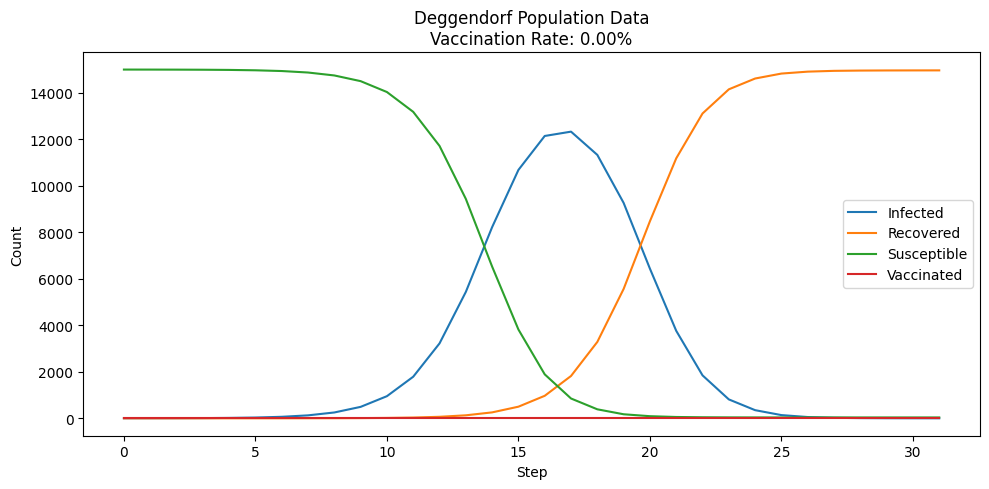

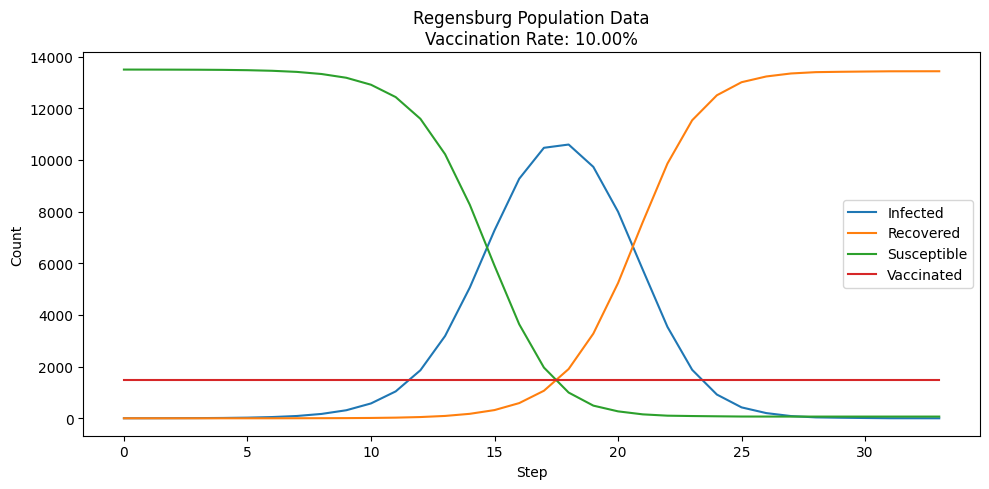

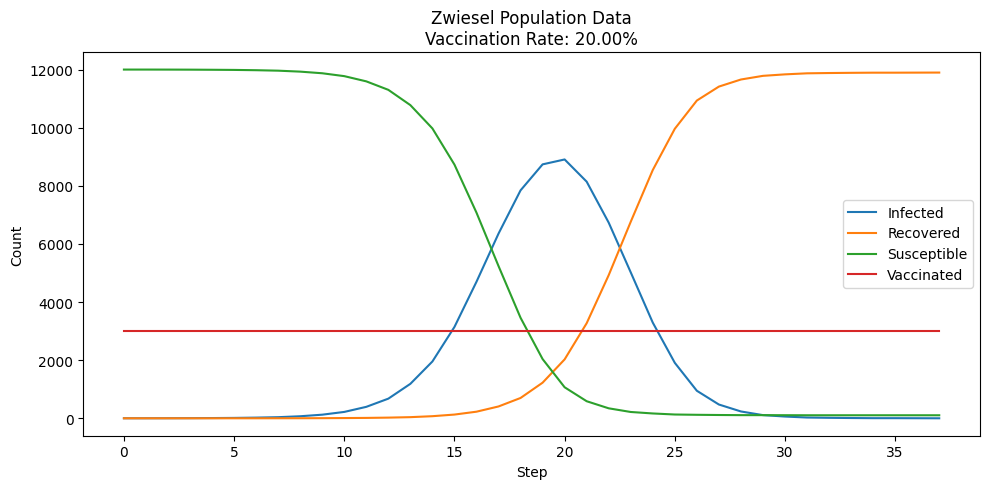

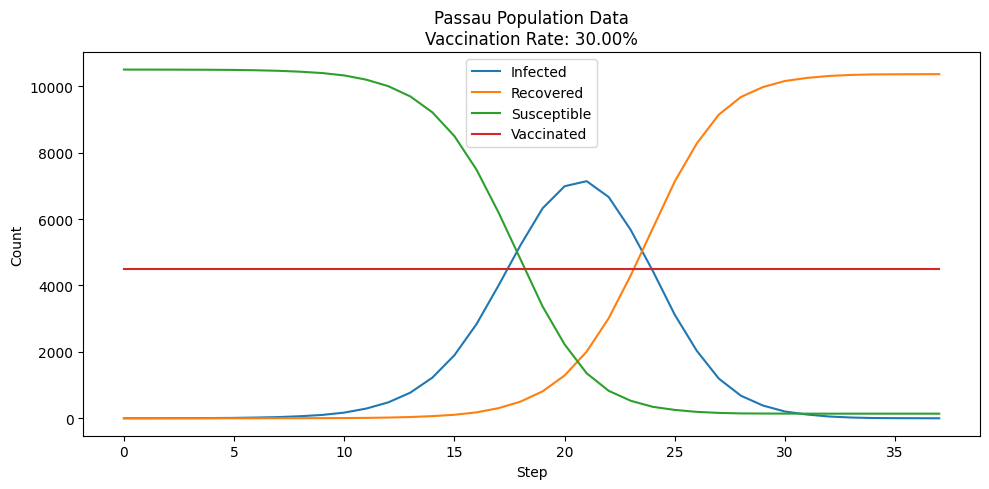

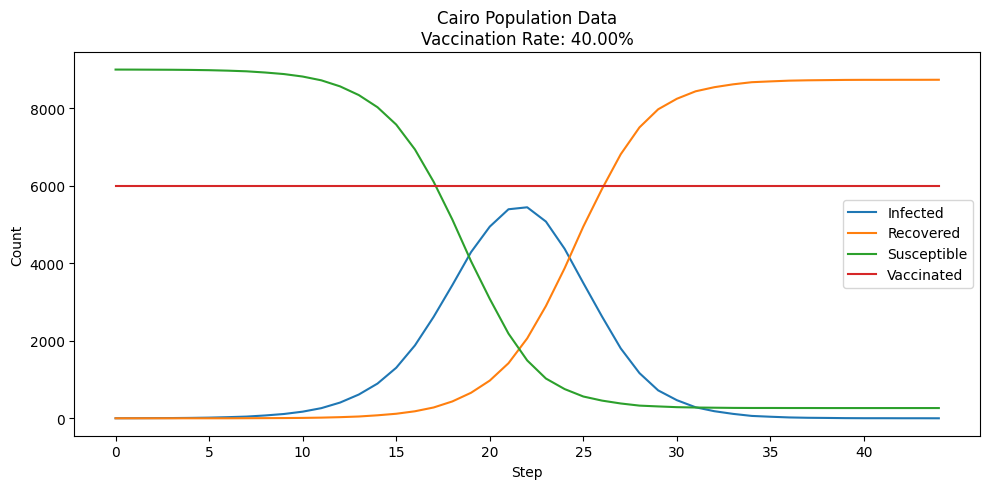

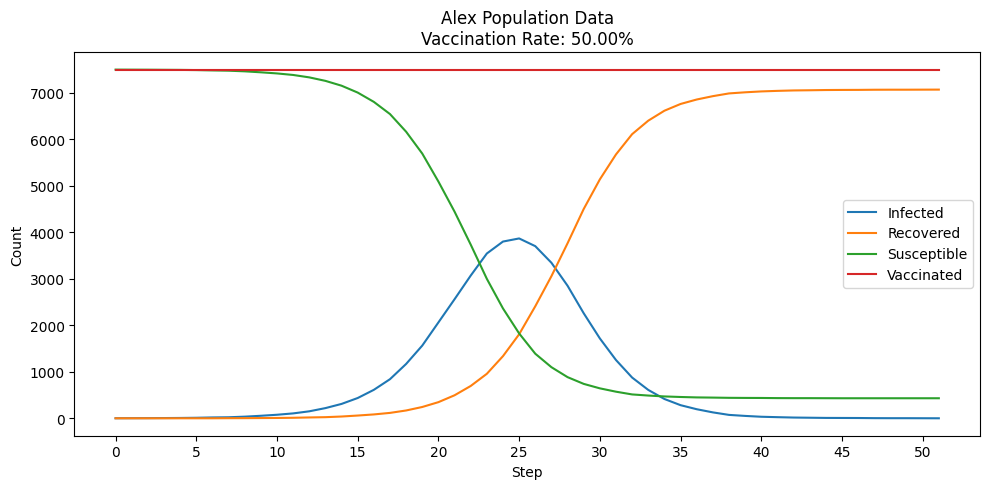

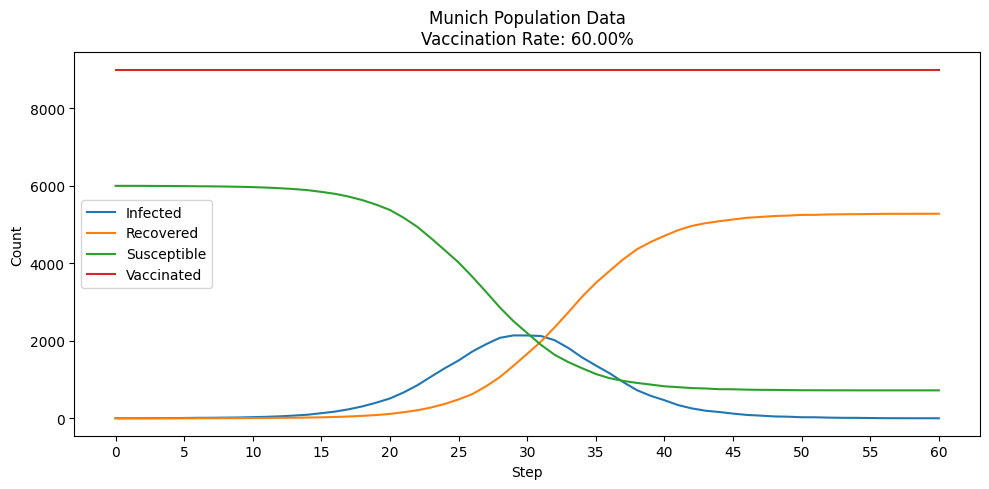

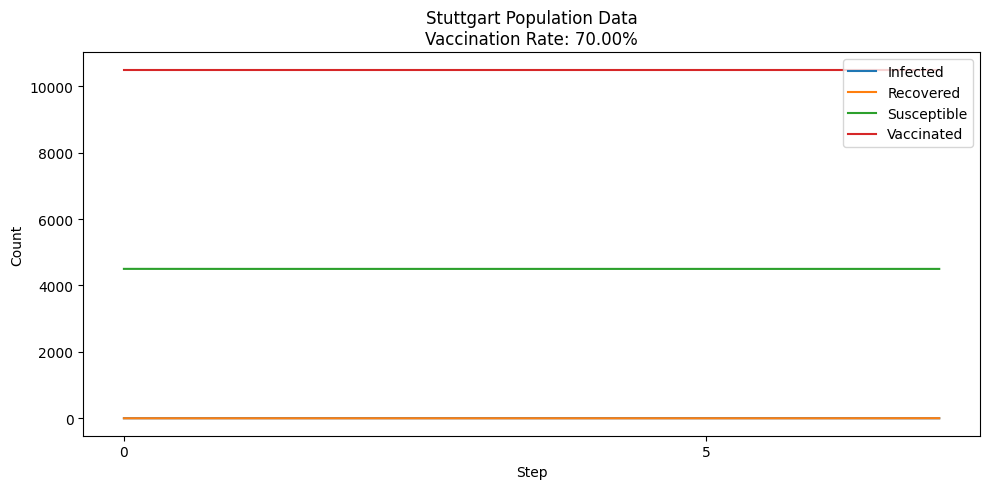

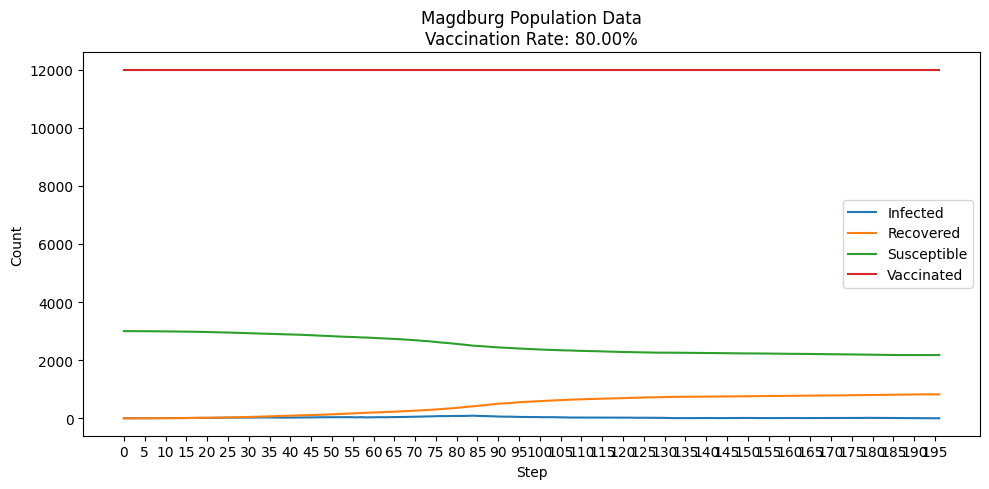

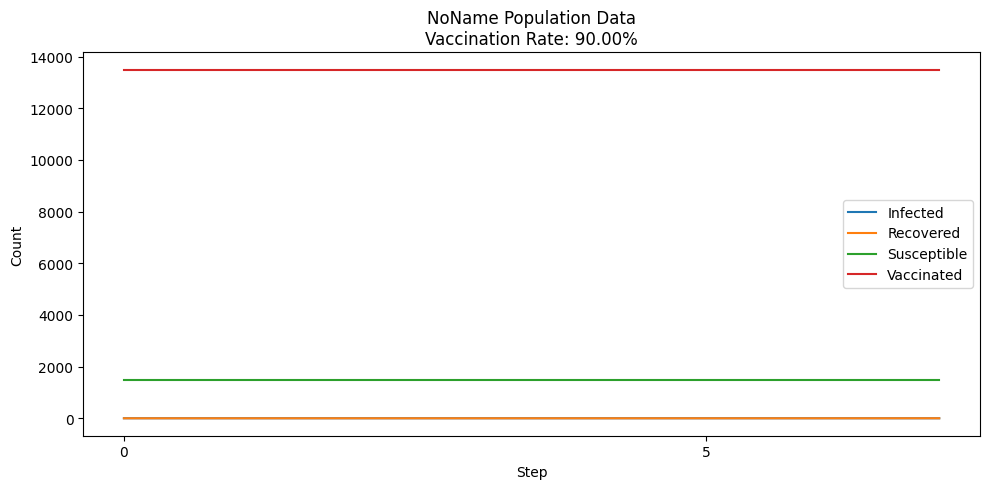

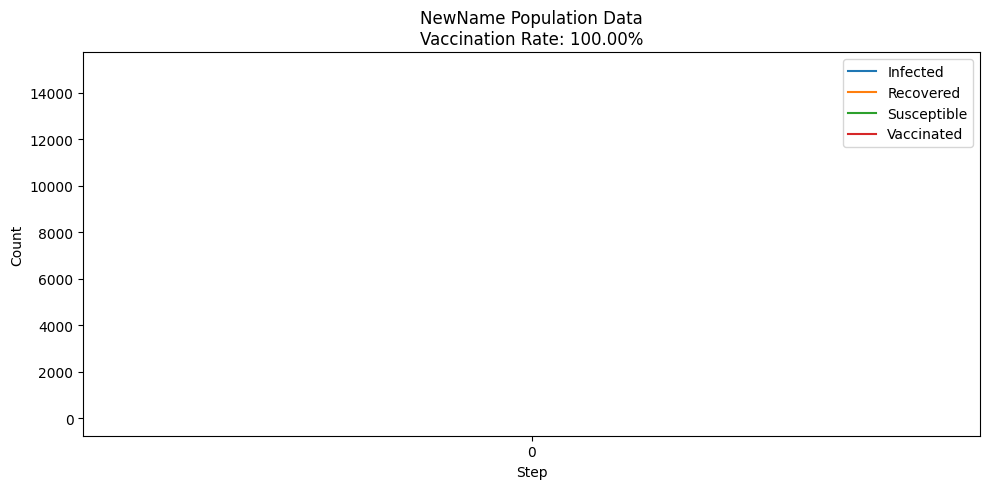

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the correct column names
column_names = ["Name", "Infected", "Recovered", "Susceptible", "Vaccinated"]

# Load the CSV file again with the correct column names
file_path = 'Disease_Details.csv'
data = pd.read_csv(file_path, names=column_names)

# Function to plot data for each population with limit when infected reaches zero
def plot_population_data_limited(data):
    # Extract the unique population names
    populations = data['Name'].unique()
    vaccination_rate = 0
    
    # Plot data for each population
    for population in populations:
        pop_data = data[data['Name'] == population]
        
        # Find the step where the number of infected reaches zero
        infected_zero_step = pop_data[pop_data['Infected'] == 0].index.min()
        
        if pd.notna(infected_zero_step):
            pop_data = pop_data.loc[:infected_zero_step]
        
        steps = range(len(pop_data))  # Use the dataframe index as steps
        
        plt.figure(figsize=(10, 5))
        plt.plot(steps, pop_data['Infected'], label='Infected')
        plt.plot(steps, pop_data['Recovered'], label='Recovered')
        plt.plot(steps, pop_data['Susceptible'], label='Susceptible')
        plt.plot(steps, pop_data['Vaccinated'], label='Vaccinated')
        plt.title(f'{population} Population Data\nVaccination Rate: {vaccination_rate:.2f}%')
        plt.xlabel('Step')
        plt.ylabel('Count')
        plt.legend()
        plt.xticks(range(0, len(pop_data), 5))  # Ensure the step numbers are shown on the x-axis
        plt.tight_layout()

        # Save the plot
        file_name = f'{vaccination_rate}_{population}_Population_Data.png'
        plt.savefig(file_name)
        plt.show()
        plt.close()
        vaccination_rate += 0.1 *100
        
# Plot the population data with limited steps and step numbers on the x-axis
plot_population_data_limited(data)


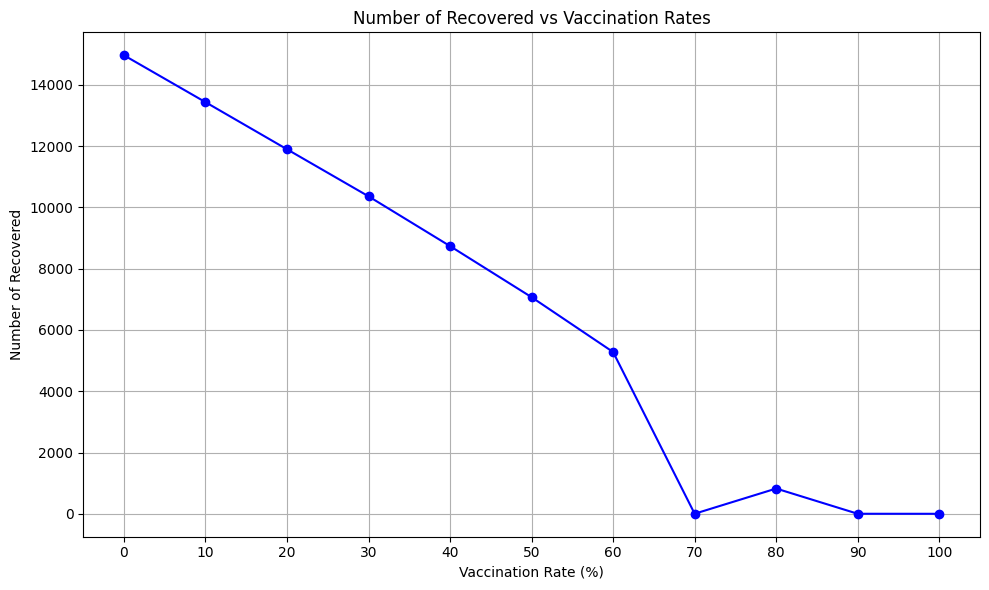

2156    14964
2157    13434
2158    11896
2159    10361
2160     8736
2161     7069
2162     5279
2163        2
2164      824
2165        1
2166        0
Name: Recovered, dtype: int64


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file with specific column names
file_path = 'Disease_Details.csv'
column_names = ["Name", "Infected", "Recovered", "Susceptible", "Vaccinated"]
data = pd.read_csv(file_path, names=column_names)

# Ensure we have at most 11 entries
data_last_11 = data.tail(11)

# Generate vaccination rates from 0% to 100% with 10% steps
vaccination_rates = range(0, 101, 10)

# Extract vaccinated and vaccination rate data
vaccinated = data_last_11['Recovered']

# Plot vaccinated against vaccination rate
plt.figure(figsize=(10, 6))
plt.plot(vaccination_rates, vaccinated, marker='o', linestyle='-', color='b')
plt.xlabel('Vaccination Rate (%)')
plt.ylabel('Number of Recovered')
plt.title('Number of Recovered vs Vaccination Rates')
plt.grid(True)
plt.xticks(vaccination_rates)
plt.tight_layout()

# Save the plot
file_name = 'Recovered_vs_Vaccination_Rates.png'
plt.savefig(file_name)
plt.show()
plt.close()

print(vaccinated)